In [62]:
from ml.dataset import get_dataloaders
from ml.models import Conv1Layer
from ml.train import Experiment
%load_ext autoreload
%autoreload 2

import logging
import torch
import torch.optim as optim
from torch import nn
from train import Trainer
from visualization import plot_results
import gc

logger = logging.getLogger("Main")
logging.basicConfig(
    filename="logger.log",
    filemode="w",
    level=logging.INFO,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [63]:
torch.manual_seed(42)
torch.use_deterministic_algorithms(True)

if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

train_loader, val_loader, test_loader = get_dataloaders()

In [64]:
def run_experiment(
        model: nn.Module,
        model_name: str,
        lr: float = 0.001,
        max_epochs: int = 20,
        patience: int = 5,
) -> tuple[float, float, Trainer]:

    loss_fn  = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr = lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", patience=2)

    trainer = Trainer(
        model = model,
        model_name = model_name,
        loss_fn = loss_fn,
        optimizer = optimizer,
        train_loader = train_loader,
        val_loader = val_loader,
        device = device,
        logger=logger,
        scheduler = scheduler,
    )

    val_loss, val_acc = trainer.train_and_validate(max_epochs = max_epochs, patience = patience)

    return val_loss, val_acc, trainer

Conv1_32: validation loss: 2.307980826349542, validation accuracy: 0.5722772277227722


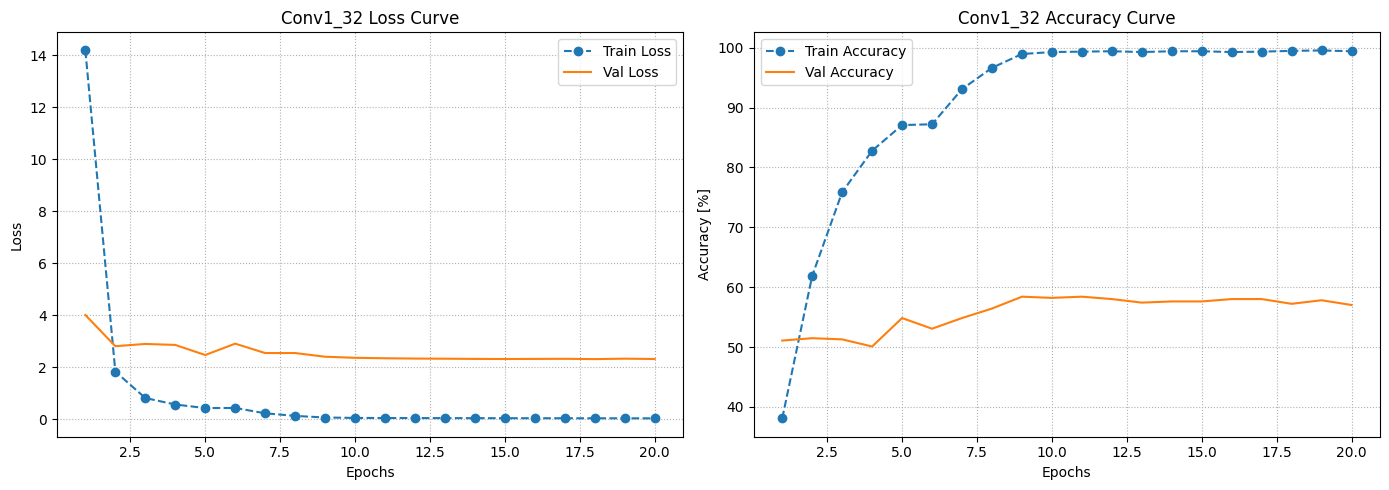

Conv1_64: validation loss: 3.12317749391688, validation accuracy: 0.5722772277227722


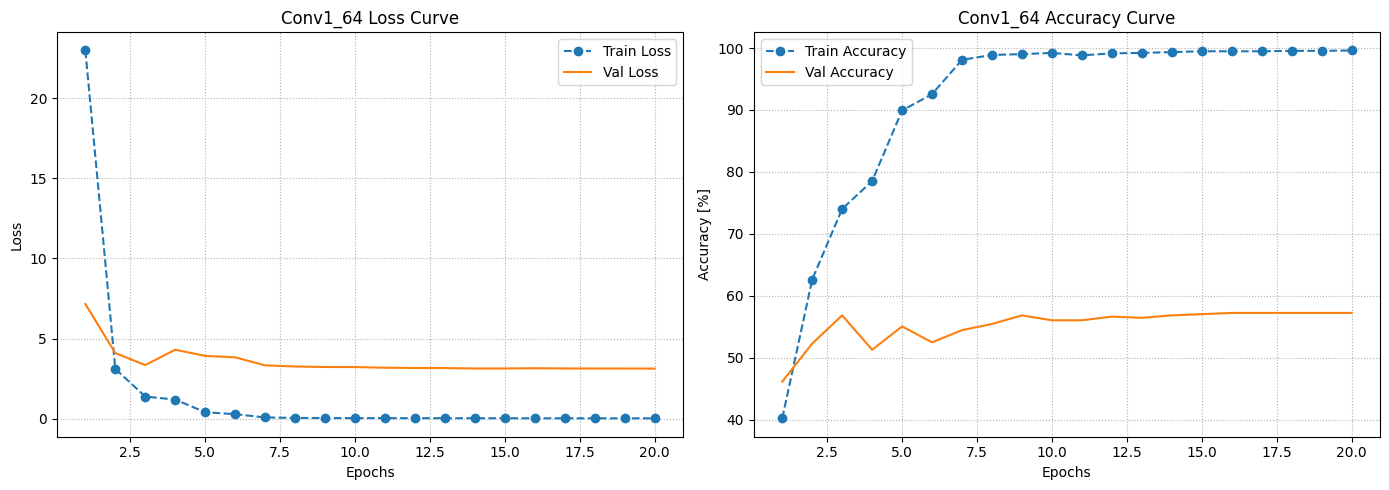

In [65]:
# this structure is created so that the initialization is made
# lazily so it doesn't consume RAM unnecesarily
all_experiments = []
experiments = [
    Experiment("Conv1_32", Conv1Layer, {"n1" : 32}),
    Experiment("Conv1_64", Conv1Layer, {"n1" : 64}),
]

for exp in experiments:
    model = exp.model_cls(**exp.kwargs)

    val_loss, val_acc, trainer = run_experiment(model = model, model_name = exp.model_name)
    print(f"{exp.model_name}: validation loss: {val_loss:.4f}, validation accuracy: {val_acc:.4f}")

    plot_results(progress = trainer.progress, model_name = exp.model_name)
    exp.progress = trainer.progress

    del model
    del trainer
    gc.collect()
    if torch.mps.is_available():
        torch.mps.empty_cache()

all_experiments.extend(experiments)